In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/owid_covid_data.csv')
df['date'] = pd.to_datetime(df['date'])
countries_df = df[df['continent'].notna()].copy()
world = df[df['location'] == 'World'].copy()

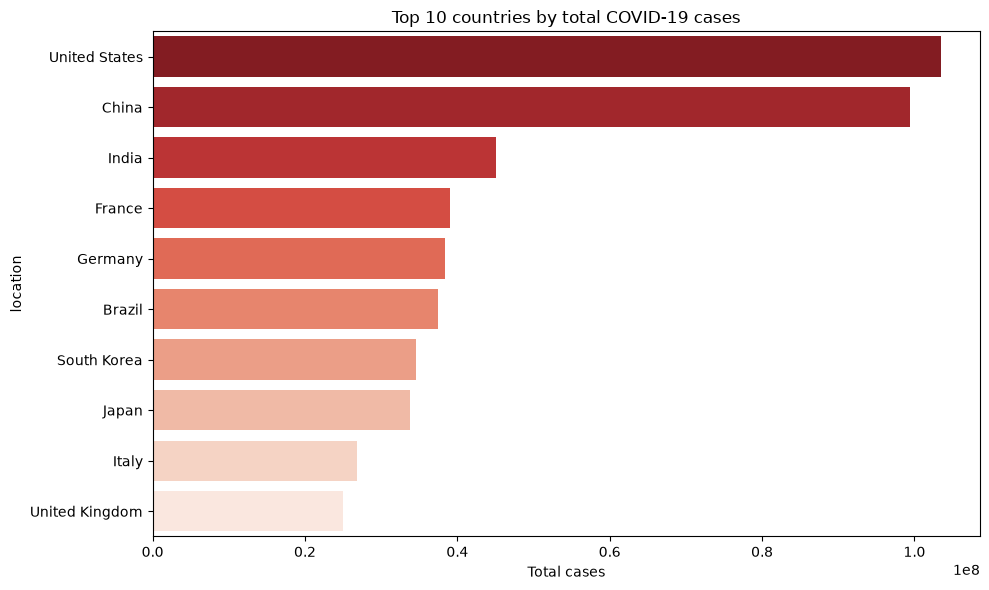

In [2]:
latest = countries_df.groupby('location').last().reset_index()
top10_cases = latest.nlargest(10, 'total_cases')[['location', 'total_cases', 'total_deaths']]

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_cases, x='total_cases', y='location',
            hue='location', palette='Reds_r', legend=False)
plt.title('Top 10 countries by total COVID-19 cases')
plt.xlabel('Total cases')
plt.tight_layout()
plt.savefig('../visuals/02_top_countries_cases.png', dpi=150)
plt.show()

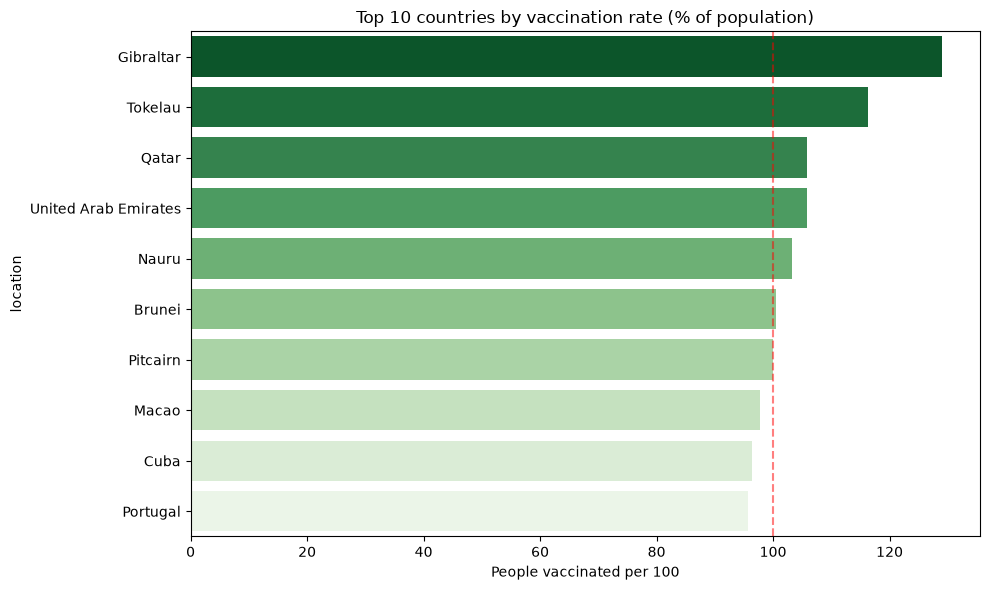

In [3]:
# Top 10 most vaccinated countries
top_vaxxed = latest.nlargest(10, 'people_vaccinated_per_hundred')[
    ['location', 'people_vaccinated_per_hundred']
].dropna()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_vaxxed, x='people_vaccinated_per_hundred', y='location',
            hue='location', palette='Greens_r', legend=False)
plt.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='100%')
plt.title('Top 10 countries by vaccination rate (% of population)')
plt.xlabel('People vaccinated per 100')
plt.tight_layout()
plt.savefig('../visuals/04_vaccination_rate.png', dpi=150)
plt.show()

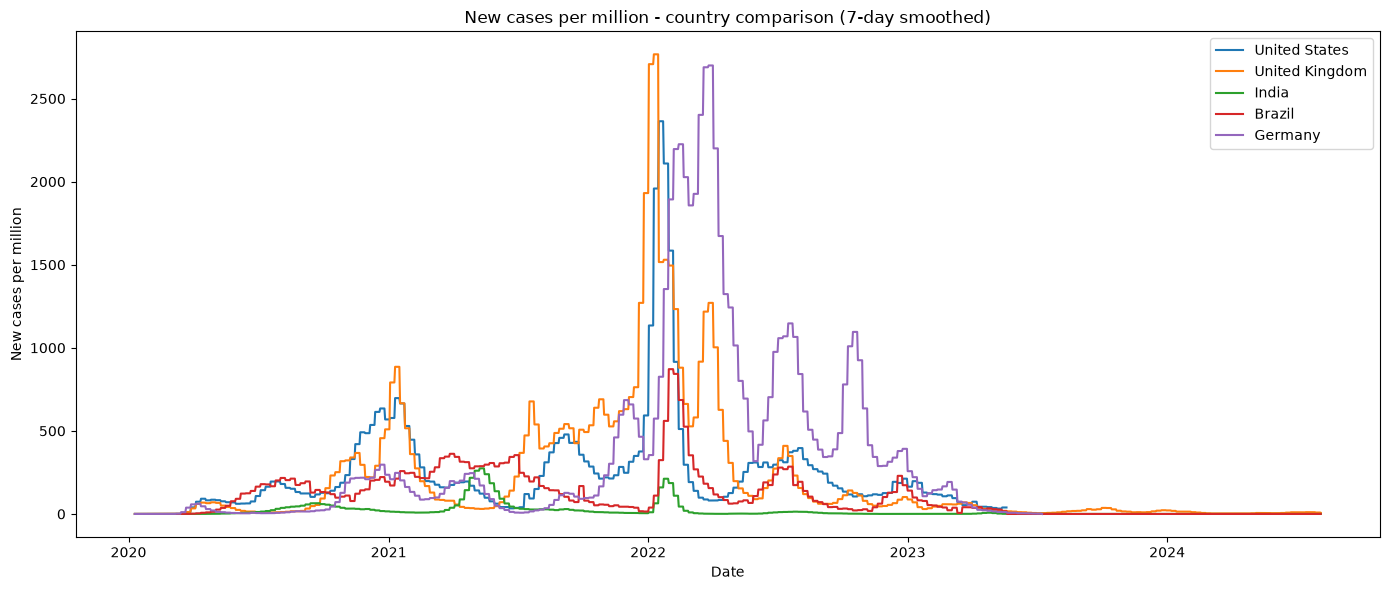

In [4]:
compare_countries = ['United States', 'United Kingdom', 'India', 'Brazil', 'Germany']
compare_df = countries_df[countries_df['location'].isin(compare_countries)]

plt.figure(figsize=(14, 6))
for country in compare_countries:
    country_data = compare_df[compare_df['location'] == country]
    plt.plot(country_data['date'],
            country_data['new_cases_smoothed_per_million'],
            label=country, linewidth=1.5)

plt.title('New cases per million - country comparison (7-day smoothed)')
plt.xlabel('Date')
plt.ylabel('New cases per million')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/05_country_comparison.png', dpi=150)
plt.show()